In [4]:
import pandas as pd

df = pd.read_csv("../data/IMDB Dataset.csv")

df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
import pandas as pd

df = pd.read_csv("../data/IMDB Dataset.csv")



In [6]:
print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [7]:
df.shape

(50000, 2)

In [8]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [10]:
print("Total Reviews:", len(df))

print("Missing Reviews:", df["review"].isnull().sum())

print("Missing Sentiments:", df["sentiment"].isnull().sum())

Total Reviews: 50000
Missing Reviews: 0
Missing Sentiments: 0


In [11]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 418


In [12]:
print(df["sentiment"].unique())

['positive' 'negative']


In [13]:
df["review"].isnull().sum()
df["sentiment"].isnull().sum()
df.duplicated().sum()
df["sentiment"].unique()

array(['positive', 'negative'], dtype=object)

In [14]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [15]:
sentiment_counts = df["sentiment"].value_counts()

print(sentiment_counts)

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

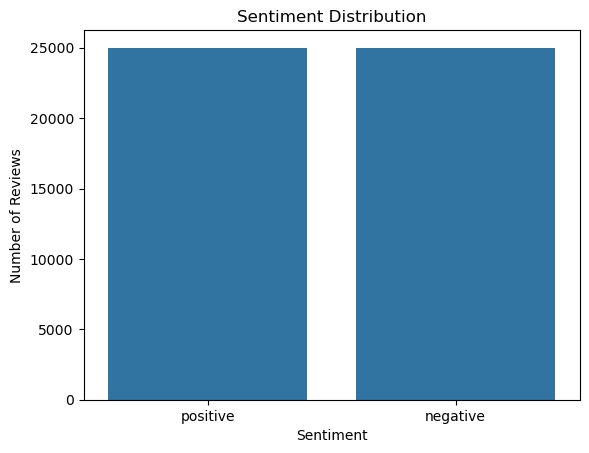

In [17]:
sns.countplot(x="sentiment", data=df)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [18]:
positive_count = sentiment_counts["positive"]
negative_count = sentiment_counts["negative"]

if positive_count == negative_count:
    print("Dataset is balanced")
else:
    print("Dataset is not balanced")
    

Dataset is balanced


In [19]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [20]:
df["word_count"] = df["review"].apply(
    lambda x: len(x.split())
)

In [21]:
df[["review", "word_count"]].head()

,review,word_count
0,One of the other reviewers has mentioned that ...,307
1,A wonderful little production. <br /><br />The...,162
2,I thought this was a wonderful way to spend ti...,166
3,Basically there's a family where a little boy ...,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",230


In [22]:
df["word_count"].mean()

231.15694

In [23]:
positive_avg = df[df["sentiment"] == "positive"]["word_count"].mean()

print(
    "Average Positive Word Count:",
    round(positive_avg, 2)
)

Average Positive Word Count: 232.85


In [24]:
negative_avg = df[df["sentiment"] == "negative"]["word_count"].mean()

print(
    "Average Negative Word Count:",
    round(negative_avg, 2)
)

Average Negative Word Count: 229.46


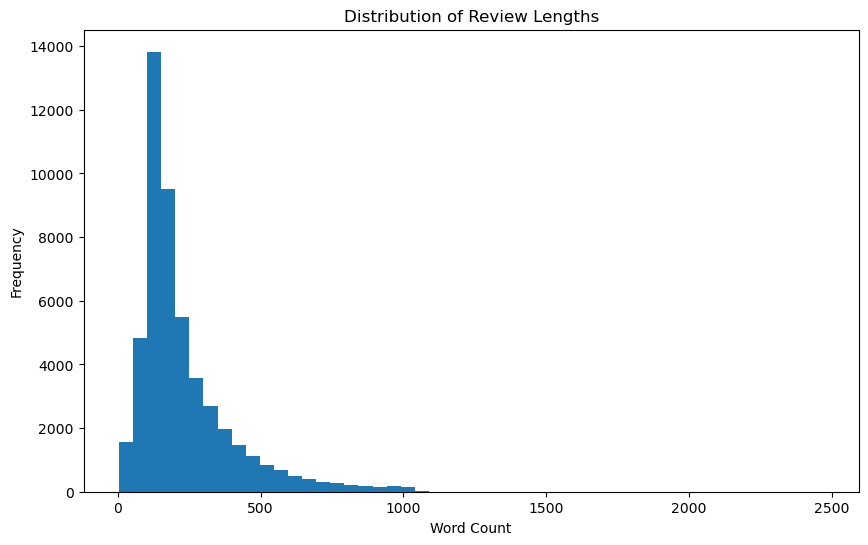

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    df["word_count"],
    bins=50
)

plt.title("Distribution of Review Lengths")
plt.xlabel("Word Count")
plt.ylabel("Frequency")

plt.show()

In [26]:
round(df["word_count"].mean(), 2)

round(
    df[df["sentiment"]=="positive"]["word_count"].mean(),
    2
)

round(
    df[df["sentiment"]=="negative"]["word_count"].mean(),
    2
)

229.46

In [27]:
df["clean_review"] = df["review"]

In [28]:
df[["review", "clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,One of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,A wonderful little production. <br /><br />The...
2,I thought this was a wonderful way to spend ti...,I thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,Basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...","Petter Mattei's ""Love in the Time of Money"" is..."


In [29]:
df["sentiment"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

In [30]:
df["sentiment"].value_counts()

sentiment
1    25000
0    25000
Name: count, dtype: int64

In [31]:
import nltk
import re

In [32]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\D3LL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [33]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [34]:
def remove_html(text):
    return re.sub(r"<.*?>", "", text)

In [35]:
remove_html(df["clean_review"][0])

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.I would say the main appeal of the show is due to the fact that it goes where other shows wo

In [36]:
def lowercase(text):
    return text.lower()

In [37]:
lowercase("HELLO WORLD")


'hello world'

In [38]:
import string

def remove_punctuation(text):
    return text.translate(
        str.maketrans('', '', string.punctuation)
    )

In [39]:
remove_punctuation("Hello!!! How are you??")

'Hello How are you'

In [40]:
stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    words = text.split()

    filtered_words = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(filtered_words)

In [41]:
remove_stopwords(
    "this is a wonderful movie and i enjoyed it"
)

'wonderful movie enjoyed'

In [42]:
ps = PorterStemmer()

In [43]:
def stem_text(text):
    words = text.split()

    stemmed_words = [
        ps.stem(word)
        for word in words
    ]

    return " ".join(stemmed_words)

In [44]:
stem_text(
    "loved loving loves movies"
)

'love love love movi'

In [45]:
def clean_text(text):

    text = remove_html(text)

    text = lowercase(text)

    text = remove_punctuation(text)

    text = remove_stopwords(text)

    text = stem_text(text)

    return text

In [46]:
clean_text(df["review"][0])

'one review mention watch 1 oz episod youll hook right exactli happen meth first thing struck oz brutal unflinch scene violenc set right word go trust show faint heart timid show pull punch regard drug sex violenc hardcor classic use wordit call oz nicknam given oswald maximum secur state penitentari focus mainli emerald citi experiment section prison cell glass front face inward privaci high agenda em citi home manyaryan muslim gangsta latino christian italian irish moreso scuffl death stare dodgi deal shadi agreement never far awayi would say main appeal show due fact goe show wouldnt dare forget pretti pictur paint mainstream audienc forget charm forget romanceoz doesnt mess around first episod ever saw struck nasti surreal couldnt say readi watch develop tast oz got accustom high level graphic violenc violenc injustic crook guard wholl sold nickel inmat wholl kill order get away well manner middl class inmat turn prison bitch due lack street skill prison experi watch oz may becom c

In [47]:
print("ORIGINAL:")
print(df["review"][0])

print("\nCLEANED:")
print(clean_text(df["review"][0]))

ORIGINAL:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due 

In [48]:
for i in range(3):
    print(clean_text(df["review"][i]))
    print("-"*50)

one review mention watch 1 oz episod youll hook right exactli happen meth first thing struck oz brutal unflinch scene violenc set right word go trust show faint heart timid show pull punch regard drug sex violenc hardcor classic use wordit call oz nicknam given oswald maximum secur state penitentari focus mainli emerald citi experiment section prison cell glass front face inward privaci high agenda em citi home manyaryan muslim gangsta latino christian italian irish moreso scuffl death stare dodgi deal shadi agreement never far awayi would say main appeal show due fact goe show wouldnt dare forget pretti pictur paint mainstream audienc forget charm forget romanceoz doesnt mess around first episod ever saw struck nasti surreal couldnt say readi watch develop tast oz got accustom high level graphic violenc violenc injustic crook guard wholl sold nickel inmat wholl kill order get away well manner middl class inmat turn prison bitch due lack street skill prison experi watch oz may becom co

In [49]:
clean_text(df["review"][0])

'one review mention watch 1 oz episod youll hook right exactli happen meth first thing struck oz brutal unflinch scene violenc set right word go trust show faint heart timid show pull punch regard drug sex violenc hardcor classic use wordit call oz nicknam given oswald maximum secur state penitentari focus mainli emerald citi experiment section prison cell glass front face inward privaci high agenda em citi home manyaryan muslim gangsta latino christian italian irish moreso scuffl death stare dodgi deal shadi agreement never far awayi would say main appeal show due fact goe show wouldnt dare forget pretti pictur paint mainstream audienc forget charm forget romanceoz doesnt mess around first episod ever saw struck nasti surreal couldnt say readi watch develop tast oz got accustom high level graphic violenc violenc injustic crook guard wholl sold nickel inmat wholl kill order get away well manner middl class inmat turn prison bitch due lack street skill prison experi watch oz may becom c

In [50]:
df["clean_review"] = df["review"].apply(clean_text)

In [51]:
df[["review", "clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one review mention watch 1 oz episod youll hoo...
1,A wonderful little production. <br /><br />The...,wonder littl product film techniqu unassum old...
2,I thought this was a wonderful way to spend ti...,thought wonder way spend time hot summer weeke...
3,Basically there's a family where a little boy ...,basic there famili littl boy jake think there ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visual stun film...


In [52]:
df.columns

Index(['review', 'sentiment', 'word_count', 'clean_review'], dtype='object')

In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [54]:
tfidf = TfidfVectorizer(
    max_features=5000
)

In [55]:
X = tfidf.fit_transform(
    df["clean_review"]
)

In [56]:
y = df["sentiment"]

In [57]:
X.shape

(50000, 5000)

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [62]:
print(X_train.shape)
print(X_test.shape)

(40000, 5000)
(10000, 5000)


In [63]:
print(X.shape)
print(X_train.shape)
print(X_test.shape)

(50000, 5000)
(40000, 5000)
(10000, 5000)


In [64]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [65]:
y_pred = lr.predict(X_test)

In [66]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8857


In [67]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.87      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [68]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4311  650]
 [ 493 4546]]


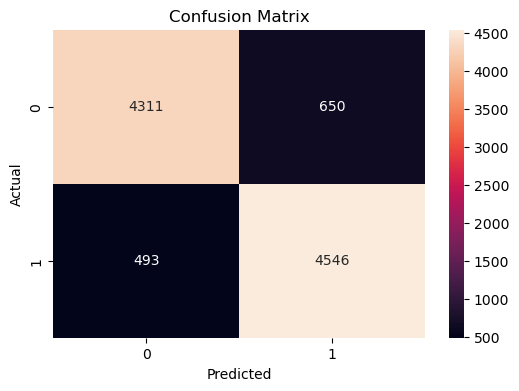

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()